In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
%matplotlib inline

In [3]:
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("train.csv")

In [5]:
print("="*70)
print("First 5 Records")
print("="*70)

print(df.head())

print("\n")

print("="*70)
print("Last 5 Records")
print("="*70)

print(df.tail())

print("\n")

print("="*70)
print("Dataset Shape")
print("="*70)

print(df.shape)

print("\n")

print("="*70)
print("Column Names")
print("="*70)

print(df.columns)

print("\n")

print("="*70)
print("Dataset Information")
print("="*70)

df.info()

print("\n")

print("="*70)
print("Data Types")
print("="*70)

print(df.dtypes)


First 5 Records
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2   

In [6]:
print("\n")

print("="*70)
print("Missing Values")
print("="*70)

print(df.isnull().sum())




Missing Values
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [7]:
print("\n")

print("="*70)
print("Duplicate Records")
print("="*70)

print(df.duplicated().sum())




Duplicate Records
0


In [8]:
print("\n")

print("="*70)
print("Statistical Summary")
print("="*70)

print(df.describe())



Statistical Summary
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [9]:
from pandas.api.types import (
    is_string_dtype,
    is_integer_dtype,
    is_float_dtype
)

categorical_columns = []
numerical_columns = []

for col in df.columns:

    if is_string_dtype(df[col]):

        categorical_columns.append(col)

    elif is_integer_dtype(df[col]) or is_float_dtype(df[col]):

        numerical_columns.append(col)

print("\n")

print("="*70)
print("Categorical Columns")
print("="*70)

print(categorical_columns)

print("\n")

print("="*70)
print("Numerical Columns")
print("="*70)

print(numerical_columns)




Categorical Columns
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


Numerical Columns
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [10]:
for col in categorical_columns:

    print("\n")

    print("="*70)
    print(col.upper())
    print("="*70)

    print(df[col].value_counts())



LOAN_ID
Loan_ID
LP001002    1
LP001003    1
LP001005    1
LP001006    1
LP001008    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    1
Name: count, Length: 614, dtype: int64


GENDER
Gender
Male      489
Female    112
Name: count, dtype: int64


MARRIED
Married
Yes    398
No     213
Name: count, dtype: int64


DEPENDENTS
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64


EDUCATION
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


SELF_EMPLOYED
Self_Employed
No     500
Yes     82
Name: count, dtype: int64


PROPERTY_AREA
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


LOAN_STATUS
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [15]:
categorical_missing = [

    "Gender",

    "Married",

    "Dependents",

    "Self_Employed"

]

for col in categorical_missing:

    df[col] = df[col].fillna(

        df[col].mode()[0]

    )


In [16]:
numerical_missing = [

    "LoanAmount",

    "Loan_Amount_Term",

    "Credit_History"

]

for col in numerical_missing:

    df[col] = df[col].fillna(

        df[col].median()

    )
print("\n")

print("="*70)
print("Missing Values After Imputation")
print("="*70)

print(df.isnull().sum())



Missing Values After Imputation
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [17]:
df["Total_Income"] = (

    df["ApplicantIncome"]

    +

    df["CoapplicantIncome"]

)

print("\n")

print("="*70)
print("Dataset with Total Income")
print("="*70)

print(df.head())



Dataset with Total Income
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  Total_Income  
0             1.0         Urban           Y        5849.0  
1         



Loan Status Distribution
Loan_Status
Y    422
N    192
Name: count, dtype: int64


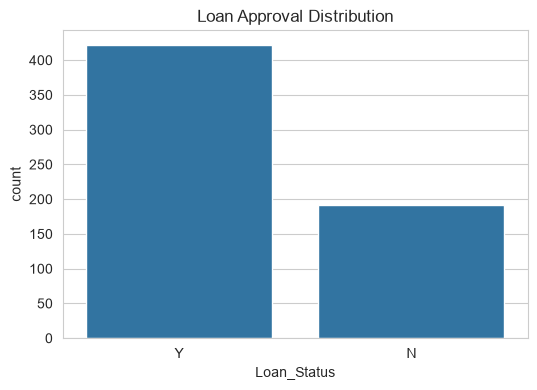

In [18]:
print("\n")

print("="*70)
print("Loan Status Distribution")
print("="*70)

print(df["Loan_Status"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(

    data=df,

    x="Loan_Status"

)

plt.title("Loan Approval Distribution")

plt.show()


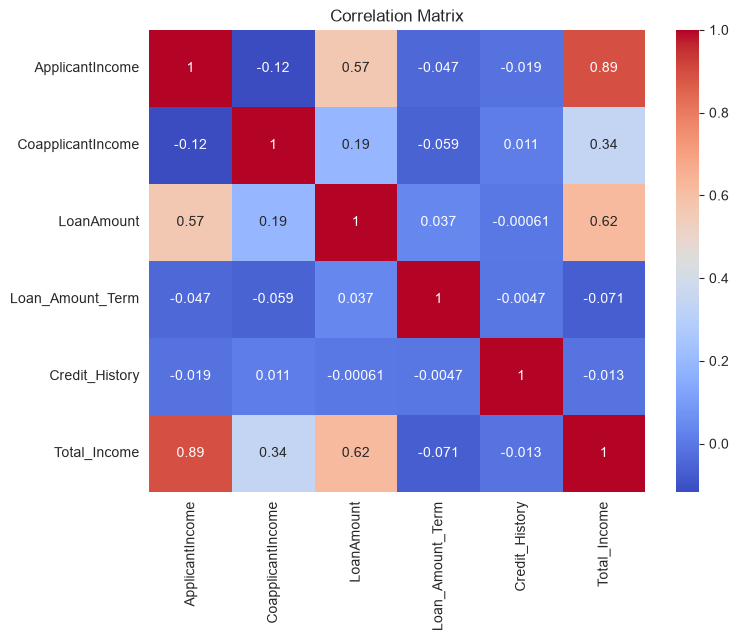

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(

    df.select_dtypes(include=np.number).corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation Matrix")

plt.show()


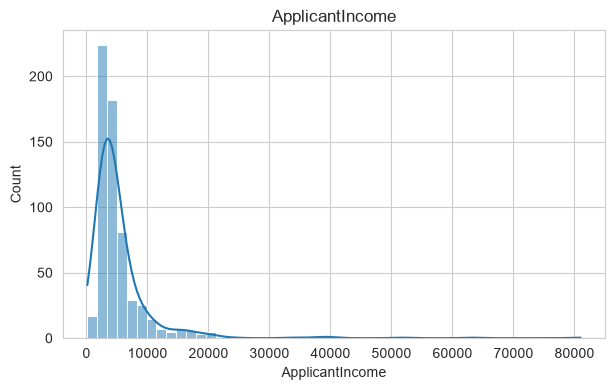

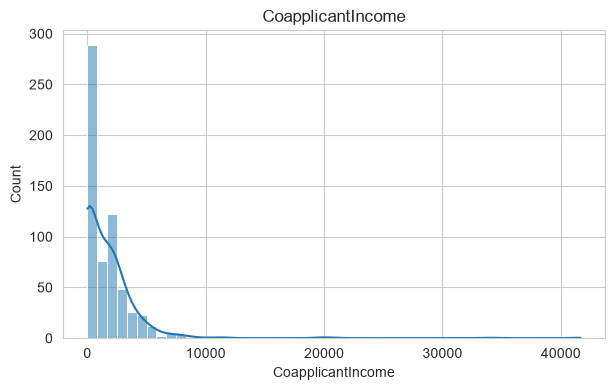

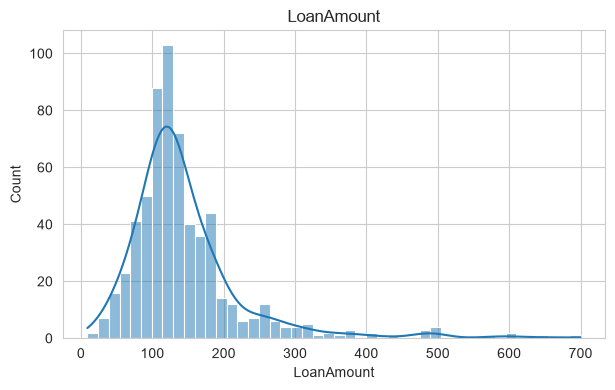

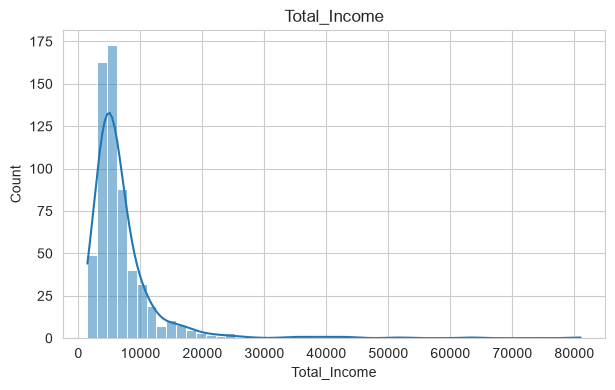

In [20]:
hist_columns = [

    "ApplicantIncome",

    "CoapplicantIncome",

    "LoanAmount",

    "Total_Income"

]

for col in hist_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(

        df[col],

        kde=True

    )

    plt.title(col)

    plt.show()


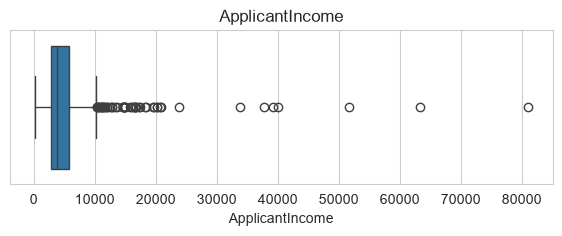

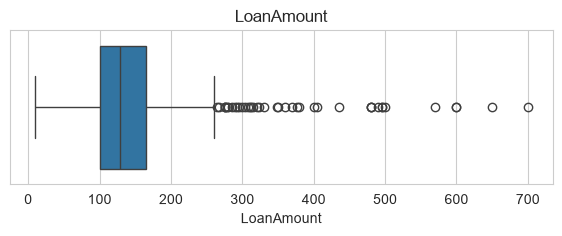

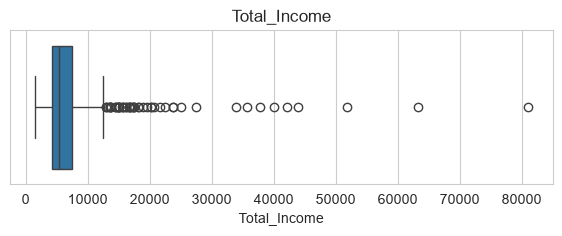

In [21]:
box_columns = [

    "ApplicantIncome",

    "LoanAmount",

    "Total_Income"

]

for col in box_columns:

    plt.figure(figsize=(7,2))

    sns.boxplot(

        x=df[col]

    )

    plt.title(col)

    plt.show()


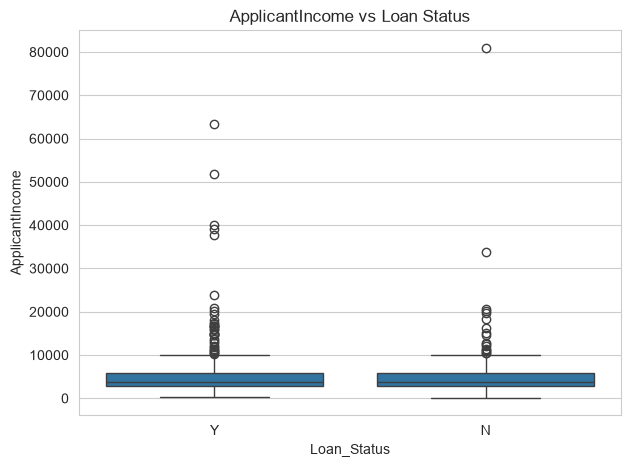

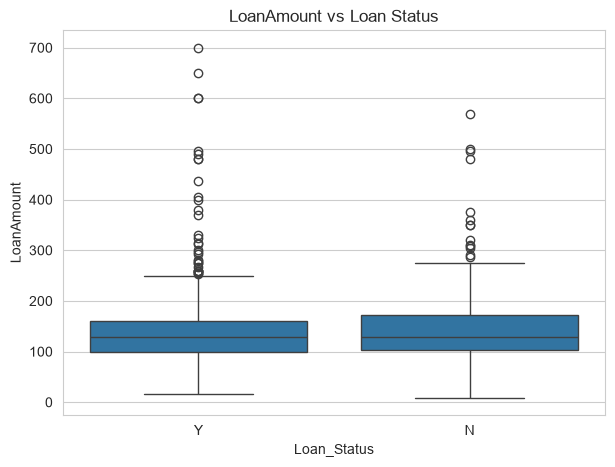

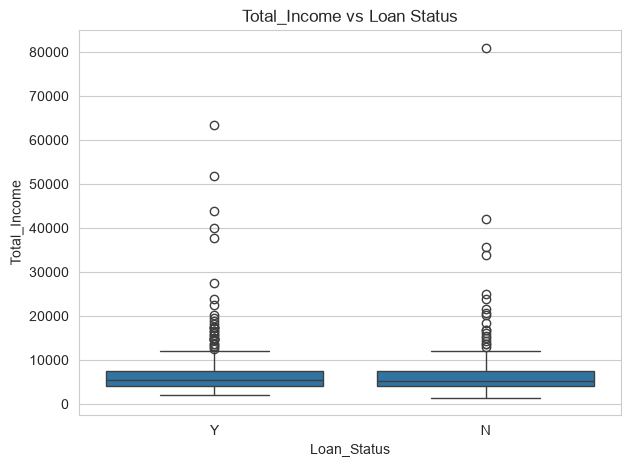

In [22]:
features = [

    "ApplicantIncome",

    "LoanAmount",

    "Total_Income"

]

for feature in features:

    plt.figure(figsize=(7,5))

    sns.boxplot(

        data=df,

        x="Loan_Status",

        y=feature

    )

    plt.title(f"{feature} vs Loan Status")

    plt.show()


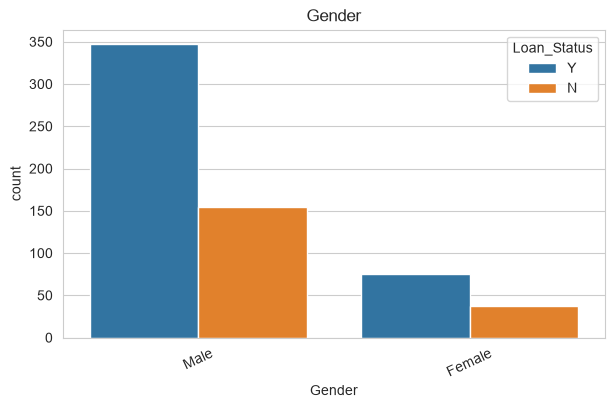

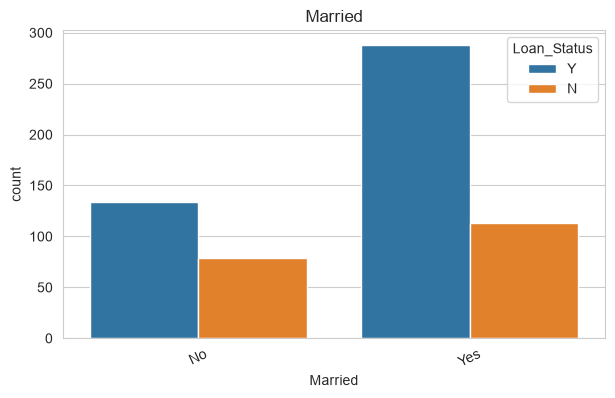

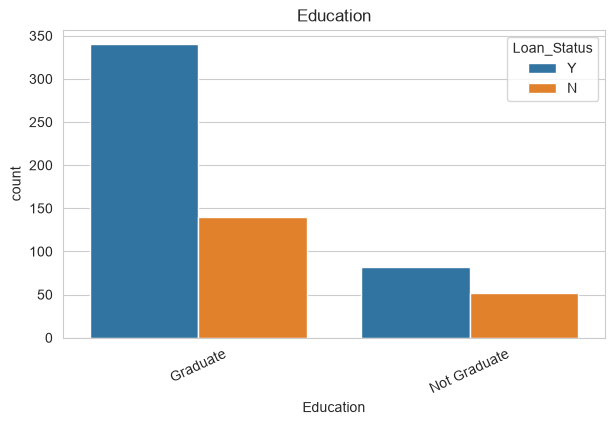

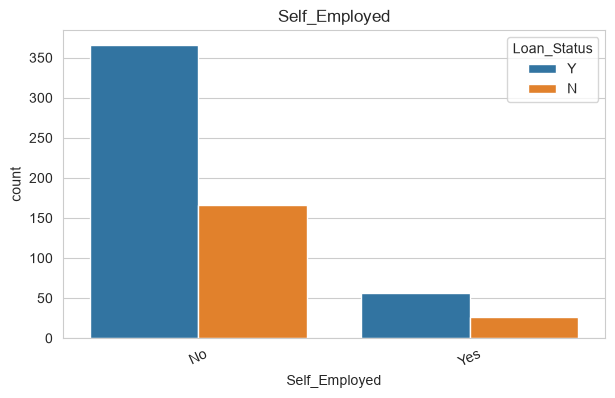

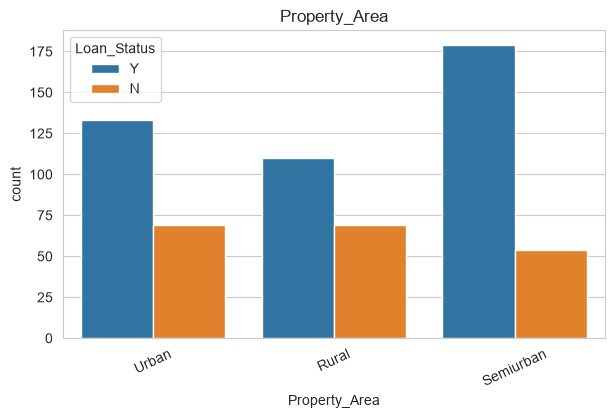

In [23]:
categorical_features = [

    "Gender",

    "Married",

    "Education",

    "Self_Employed",

    "Property_Area"

]

for feature in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(

        data=df,

        x=feature,

        hue="Loan_Status"

    )

    plt.xticks(rotation=25)

    plt.title(feature)

    plt.show()


In [24]:
X = df.drop(

    columns=[

        "Loan_ID",

        "Loan_Status"

    ]

)

In [25]:
y = df["Loan_Status"]

print("\n")

print("="*70)
print("Input Features")
print("="*70)

print(X.head())

print("\n")

print("="*70)
print("Target Variable")
print("="*70)

print(y.head())

print("\n")

print("Input Shape :", X.shape)

print("Target Shape:", y.shape)




Input Features
  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No          0      Graduate            No             5849   
1   Male     Yes          1      Graduate            No             4583   
2   Male     Yes          0      Graduate           Yes             3000   
3   Male     Yes          0  Not Graduate            No             2583   
4   Male      No          0      Graduate            No             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

  Property_Area  Total_Income  
0         Urban        5849.0  
1         Rural        6091.0  
2        

In [26]:
df["Dependents"] = df["Dependents"].replace("3+", "3")


In [27]:
df["Dependents"] = df["Dependents"].astype(int)


In [28]:
categorical_columns = [

    "Gender",

    "Married",

    "Education",

    "Self_Employed",

    "Property_Area"

]

df = pd.get_dummies(

    df,

    columns=categorical_columns,

    drop_first=True,

    dtype=int

)


In [29]:
df["Loan_Status"] = df["Loan_Status"].map({

    "Y":1,

    "N":0

})


In [30]:
X = df.drop(

    columns=[

        "Loan_ID",

        "Loan_Status"

    ]

)

y = df["Loan_Status"]

print("="*70)
print("Encoded Dataset")
print("="*70)

print(X.head())


Encoded Dataset
   Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0           0             5849                0.0       128.0   
1           1             4583             1508.0       128.0   
2           0             3000                0.0        66.0   
3           0             2583             2358.0       120.0   
4           0             6000                0.0       141.0   

   Loan_Amount_Term  Credit_History  Total_Income  Gender_Male  Married_Yes  \
0             360.0             1.0        5849.0            1            0   
1             360.0             1.0        6091.0            1            1   
2             360.0             1.0        3000.0            1            1   
3             360.0             1.0        4941.0            1            1   
4             360.0             1.0        6000.0            1            0   

   Education_Not Graduate  Self_Employed_Yes  Property_Area_Semiurban  \
0                       0                  0 

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Shape")

print(X_train.shape)

print(y_train.shape)

print("\nTesting Shape")

print(X_test.shape)

print(y_test.shape)



Training Shape
(491, 13)
(491,)

Testing Shape
(123, 13)
(123,)


In [32]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(

    random_state=42

)

dt_model.fit(

    X_train,

    y_train

)

print("\nDecision Tree Model Trained Successfully!")



Decision Tree Model Trained Successfully!


In [33]:
y_pred = dt_model.predict(

    X_test

)

y_prob = dt_model.predict_proba(

    X_test

)

In [34]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score

)

accuracy = accuracy_score(

    y_test,

    y_pred

)

precision = precision_score(

    y_test,

    y_pred

)

recall = recall_score(

    y_test,

    y_pred

)

f1 = f1_score(

    y_test,

    y_pred

)

print("\n")

print("="*70)
print("Default Decision Tree Performance")
print("="*70)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")




Default Decision Tree Performance
Accuracy  : 0.7642
Precision : 0.8500
Recall    : 0.8000
F1 Score  : 0.8242


In [35]:
from sklearn.model_selection import GridSearchCV

parameters = {

    "criterion":[

        "gini",

        "entropy"

    ],

    "max_depth":[

        2,

        3,

        4,

        5,

        6,

        8,

        10

    ],

    "min_samples_split":[

        2,

        5,

        10,

        20

    ]

}

grid = GridSearchCV(

    estimator=DecisionTreeClassifier(

        random_state=42

    ),

    param_grid=parameters,

    cv=5,

    scoring="accuracy"

)

grid.fit(

    X_train,

    y_train

)

print("\n")

print("="*70)
print("Best Parameters")
print("="*70)

print(grid.best_params_)





Best Parameters
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 20}


In [36]:
best_model = grid.best_estimator_

best_predictions = best_model.predict(

    X_test

)


In [37]:
best_accuracy = accuracy_score(

    y_test,

    best_predictions

)

best_precision = precision_score(

    y_test,

    best_predictions

)

best_recall = recall_score(

    y_test,

    best_predictions

)

best_f1 = f1_score(

    y_test,

    best_predictions

)

print("\n")

print("="*70)
print("Best Decision Tree Performance")
print("="*70)

print(f"Accuracy  : {best_accuracy:.4f}")

print(f"Precision : {best_precision:.4f}")

print(f"Recall    : {best_recall:.4f}")

print(f"F1 Score  : {best_f1:.4f}")




Best Decision Tree Performance
Accuracy  : 0.8537
Precision : 0.8454
Recall    : 0.9647
F1 Score  : 0.9011


In [38]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    best_model,

    X,

    y,

    cv=5,

    scoring="accuracy"

)

print("\n")

print("="*70)
print("Cross Validation")
print("="*70)

print(cv_scores)

print("\nAverage Accuracy")

print(cv_scores.mean())




Cross Validation
[0.78861789 0.7398374  0.7804878  0.83739837 0.82786885]

Average Accuracy
0.79484206317473


In [39]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("\n")

print("="*70)
print("Feature Importance")
print("="*70)

print(importance)




Feature Importance
                    Feature  Importance
5            Credit_History    0.800020
6              Total_Income    0.105586
1           ApplicantIncome    0.060935
11  Property_Area_Semiurban    0.033458
0                Dependents    0.000000
4          Loan_Amount_Term    0.000000
3                LoanAmount    0.000000
2         CoapplicantIncome    0.000000
7               Gender_Male    0.000000
8               Married_Yes    0.000000
9    Education_Not Graduate    0.000000
10        Self_Employed_Yes    0.000000
12      Property_Area_Urban    0.000000


Confusion Matrix
[[23 15]
 [ 3 82]]


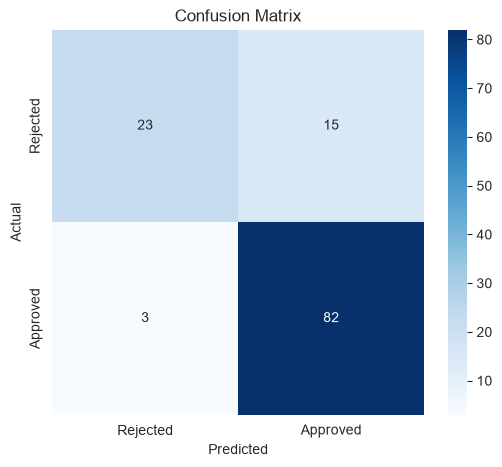

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    best_predictions

)

print("="*70)
print("Confusion Matrix")
print("="*70)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Rejected","Approved"],

    yticklabels=["Rejected","Approved"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [41]:
from sklearn.metrics import classification_report

print("\n")

print("="*70)
print("Classification Report")
print("="*70)

print(

    classification_report(

        y_test,

        best_predictions,

        target_names=["Rejected","Approved"]

    )

)




Classification Report
              precision    recall  f1-score   support

    Rejected       0.88      0.61      0.72        38
    Approved       0.85      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



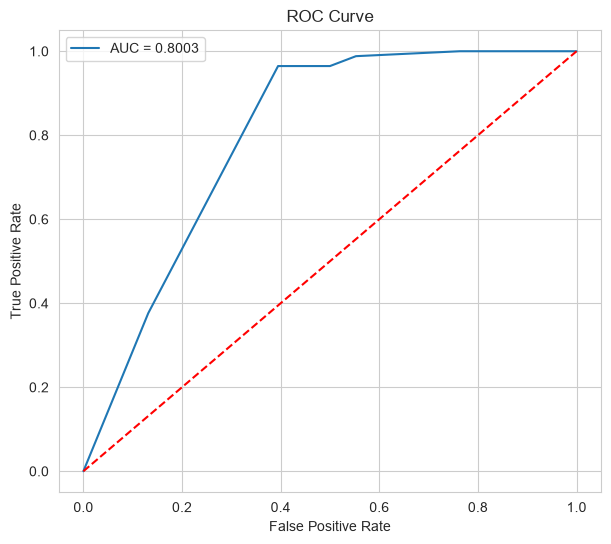


ROC AUC Score : 0.8003095975232198


In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

probability = best_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(

    y_test,

    probability

)

auc_score = roc_auc_score(

    y_test,

    probability

)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc_score:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="red"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("\nROC AUC Score :", auc_score)


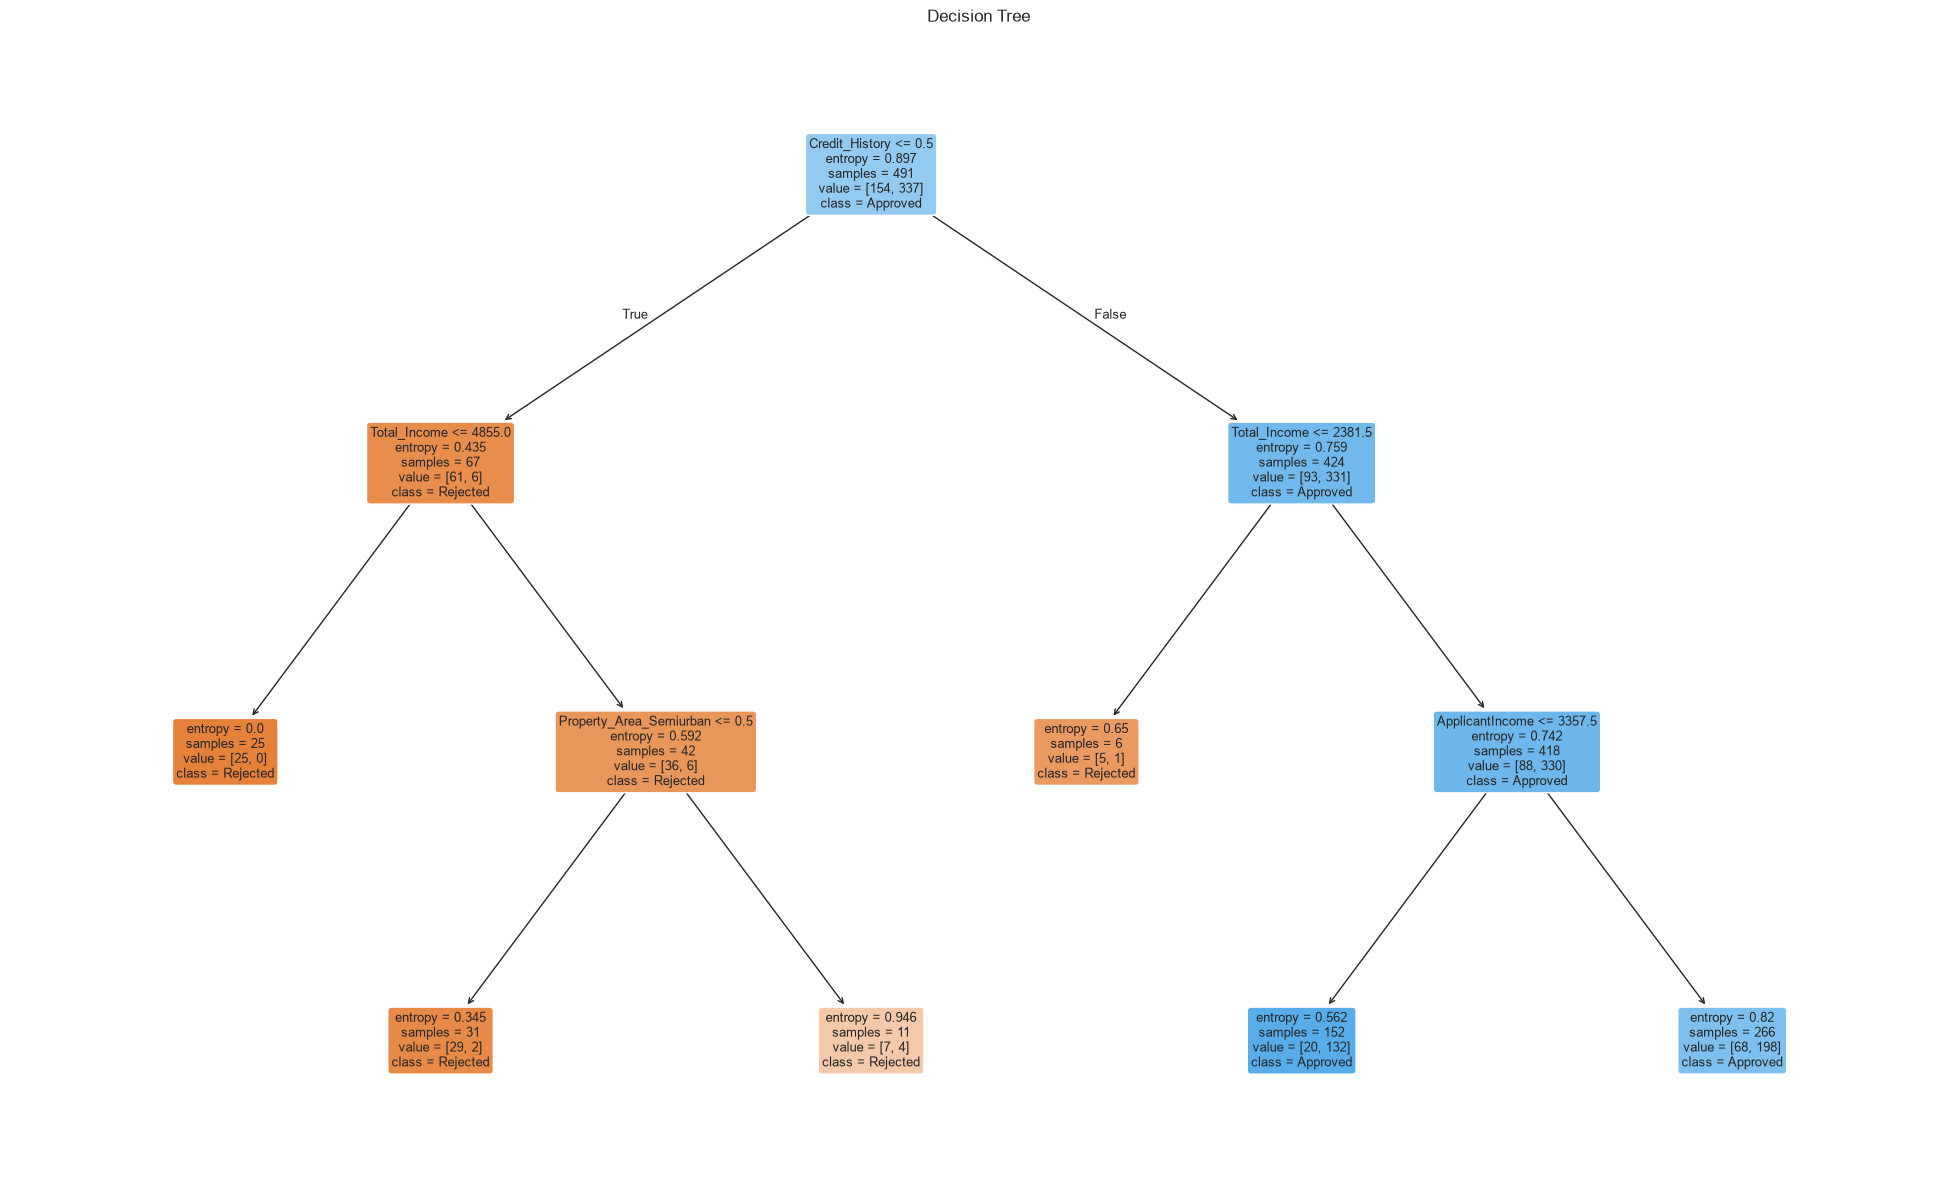

In [43]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,15))

plot_tree(

    best_model,

    feature_names=X.columns,

    class_names=["Rejected","Approved"],

    filled=True,

    rounded=True,

    fontsize=9

)

plt.title("Decision Tree")

plt.show()


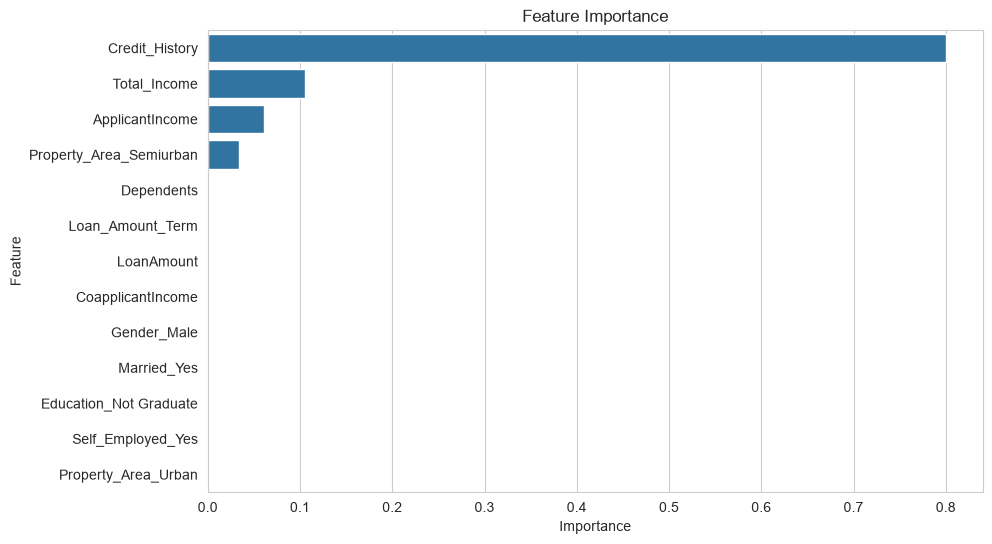

In [44]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.show()


In [45]:
new_applicant = pd.DataFrame({

    "Dependents":[1],

    "ApplicantIncome":[5000],

    "CoapplicantIncome":[1500],

    "LoanAmount":[150],

    "Loan_Amount_Term":[360],

    "Credit_History":[1],

    "Total_Income":[6500],

    "Gender_Male":[1],

    "Married_Yes":[1],

    "Education_Not Graduate":[0],

    "Self_Employed_Yes":[0],

    "Property_Area_Semiurban":[1],

    "Property_Area_Urban":[0]

})

prediction = best_model.predict(

    new_applicant

)

probability = best_model.predict_proba(

    new_applicant

)

print("\n")

print("="*70)
print("Loan Prediction")
print("="*70)

if prediction[0] == 1:

    print("Loan Status : APPROVED")

else:

    print("Loan Status : REJECTED")

print("\nPrediction Probability")

print(probability)




Loan Prediction
Loan Status : APPROVED

Prediction Probability
[[0.2556391 0.7443609]]


In [46]:
from joblib import dump

dump(

    best_model,

    "loan_decision_tree_model.joblib"

)

print("\nModel Saved Successfully!")


Model Saved Successfully!


In [47]:
from joblib import load

loaded_model = load(

    "loan_decision_tree_model.joblib"

)

print("Saved Model Loaded Successfully!")

Saved Model Loaded Successfully!


In [48]:
prediction = loaded_model.predict(

    new_applicant

)

print("\nPrediction Using Loaded Model")

if prediction[0] == 1:

    print("Loan Approved")

else:

    print("Loan Rejected")


Prediction Using Loaded Model
Loan Approved


In [49]:
test_df = pd.read_csv("test.csv")

In [50]:
loan_ids = test_df["Loan_ID"]

In [51]:
categorical_missing = [

    "Gender",

    "Married",

    "Dependents",

    "Self_Employed"

]

for col in categorical_missing:

    test_df[col] = test_df[col].fillna(

        test_df[col].mode()[0]

    )

numerical_missing = [

    "LoanAmount",

    "Loan_Amount_Term",

    "Credit_History"

]

for col in numerical_missing:

    test_df[col] = test_df[col].fillna(

        test_df[col].median()

    )

In [52]:
test_df["Dependents"] = test_df["Dependents"].replace(

    "3+",

    "3"

).astype(int)

In [53]:
test_df["Total_Income"] = (

    test_df["ApplicantIncome"]

    +

    test_df["CoapplicantIncome"]

)


In [54]:
test_df = pd.get_dummies(

    test_df,

    columns=[

        "Gender",

        "Married",

        "Education",

        "Self_Employed",

        "Property_Area"

    ],

    drop_first=True,

    dtype=int

)


In [55]:
test_features = test_df.drop(

    columns=["Loan_ID"]

)


In [56]:
test_features = test_features.reindex(

    columns=X.columns,

    fill_value=0

)

predictions = loaded_model.predict(

    test_features

)

submission = pd.DataFrame({

    "Loan_ID":loan_ids,

    "Loan_Status":np.where(

        predictions==1,

        "Y",

        "N"

    )

})

print("\n")

print("="*70)
print("Test Dataset Predictions")
print("="*70)

print(submission.head())

submission.to_csv(

    "Loan_Predictions.csv",

    index=False

)

print("\nPrediction File Saved Successfully!")




Test Dataset Predictions
    Loan_ID Loan_Status
0  LP001015           Y
1  LP001022           Y
2  LP001031           Y
3  LP001035           Y
4  LP001051           Y

Prediction File Saved Successfully!


In [57]:
print("\n")

print("="*70)
print("Loan Approval Prediction using Decision Tree")
print("="*70)

print(f"Training Samples        : {X_train.shape[0]}")

print(f"Testing Samples         : {X_test.shape[0]}")

print(f"Total Features          : {X.shape[1]}")

print(f"\nAccuracy               : {best_accuracy:.4f}")

print(f"Precision              : {best_precision:.4f}")

print(f"Recall                 : {best_recall:.4f}")

print(f"F1 Score               : {best_f1:.4f}")

print(f"ROC AUC Score          : {auc_score:.4f}")

print(f"Cross Validation       : {cv_scores.mean():.4f}")

print("\nModel Status : Ready for Deployment")

print("="*70)

print("\nProject Completed Successfully!")



Loan Approval Prediction using Decision Tree
Training Samples        : 491
Testing Samples         : 123
Total Features          : 13

Accuracy               : 0.8537
Precision              : 0.8454
Recall                 : 0.9647
F1 Score               : 0.9011
ROC AUC Score          : 0.8003
Cross Validation       : 0.7948

Model Status : Ready for Deployment

Project Completed Successfully!
